# Urine Data Analysis

With the cleaned and individually exported data, now the data is ready to be fine tuned and analysed. Urine data will be first analyzed before moving onto the blood lab analysis.

Out of the urine labs that were cleaned, the focus will be on the values that could be more directly associated with metabolic syndrome/conditions. The urine labs that will be analyzed are as follows:
 * Albumin
 * Creatinine
 * Iodine (thyroid function)

Albumin is a way to assess the kidney function but it also can be used to see the nutritional status of a person. 

Creatinine is another parameter that is used to assess kidney function.

Iodine is an element that contributes to thyroid function and therefore, more directly associated with the metabolism. 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
current_directory = os.getcwd()
print(current_directory)

C:\Users\chungs4\Documents\GitHub\portfolio_ds_projects\NHANES_analysis


In [3]:
df_d = pd.read_csv('cleaned_demographics.csv')
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_cr = pd.read_csv('urine_cr_alb.csv')

In [4]:
df_d.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109263.0,1.0,2.0,6.0,NaN,NaN,4.66
1,109264.0,2.0,13.0,1.0,NaN,NaN,0.83
2,109265.0,1.0,2.0,3.0,NaN,NaN,3.06
3,109266.0,2.0,29.0,6.0,5.0,3.0,5.00
4,109269.0,1.0,2.0,2.0,NaN,NaN,0.96


In [5]:
df_d.isna().sum()

participant_id              0
gender                      0
age_year                    0
race                        0
education_level          5756
marital_status           5756
family_income_poverty    1847
dtype: int64

In [6]:
df_d.describe()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
count,14300.000000,14300.000000,14300.000000,14300.000000,8544.000000,8544.000000,12453.000000
mean,117068.670280,1.504545,33.861818,3.482797,3.554775,1.694640,2.385320
std,4501.643618,0.499997,25.162121,1.625440,1.210994,2.613598,1.625954
min,109263.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,113170.750000,1.000000,10.000000,3.000000,3.000000,1.000000,1.010000
50%,117081.500000,2.000000,31.000000,3.000000,4.000000,1.000000,1.940000
75%,120974.250000,2.000000,56.000000,4.000000,4.000000,2.000000,3.850000
max,124822.000000,2.000000,80.000000,7.000000,9.000000,99.000000,5.000000


Current data analysis will focus on adults aged 18 or older. Subjects that are younger than 18 will be removed.

In [7]:
adults = df_d[df_d['age_year'] >= 18]

In [8]:
adults.describe()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
count,8965.000000,8965.000000,8965.000000,8965.000000,8544.000000,8544.000000,7705.000000
mean,117107.849637,1.513999,49.465142,3.484551,3.554775,1.694640,2.558740
std,4501.048325,0.499832,18.457564,1.574461,1.210994,2.613598,1.627623
min,109266.000000,1.000000,18.000000,1.000000,1.000000,1.000000,0.000000
25%,113211.000000,1.000000,33.000000,3.000000,3.000000,1.000000,1.170000
50%,117091.000000,2.000000,50.000000,3.000000,4.000000,1.000000,2.160000
75%,121022.000000,2.000000,64.000000,4.000000,4.000000,2.000000,4.140000
max,124822.000000,2.000000,80.000000,7.000000,9.000000,99.000000,5.000000


The next is anthropometry (body measures). First, the question is how much of the documented samples is considered obese. The BMI cutoffs are as follows:
 * less than 18 kg/m^2: underweight
 * 18-24.9 kg/m^2: normal weight
 * 25-29.9 kg/m^2: overweight
 * 30-39.9 kg/m^2: obese
 * greater than 40 kg/m^2: morbidly obese


In [9]:
df_a.isna().sum()

participant_id                 0
weight_kg                     32
weight_comment             13519
recumbent_length_cm        12637
standing_height              950
standing_height_comment    13936
bmi                          970
bmi_category_child          9358
upper_leg_cm                3123
upper_arm_cm                 617
arm_circumference_cm         623
waist_circ_cm               1533
hip_circ_cm                 4245
dtype: int64

Since this data analysis focuses on evaluating BMI, the subjects that are missing the BMI should be dropped. By joining the adults data frame with the anthropometry (in the next steps to come), subjects under the age 18 will automatically be removed. 

In [10]:
df_a = df_a.dropna(subset=['bmi'])

In [11]:
df_a.isna().sum()

participant_id                 0
weight_kg                      0
weight_comment             12601
recumbent_length_cm        12571
standing_height                0
standing_height_comment    13038
bmi                            0
bmi_category_child          8388
upper_leg_cm                2177
upper_arm_cm                 460
arm_circumference_cm         461
waist_circ_cm                603
hip_circ_cm                 3296
dtype: int64

Columns that are more pertinent to pediatric population (recumbent length, BMI child category) will be dropped.

Some of the subjects are wearing clothes or have medical appliances when they are getting their weight measured. However, clothing generally only tends to add up to about 5 lbs and the weight of medical appliances that generally are on the persons are typically negligible so the decision was made to drop the weight comment column. 

In [12]:
df_a.columns

Index(['participant_id', 'weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment', 'bmi',
       'bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'],
      dtype='object')

In [13]:
df_a = df_a.drop(['recumbent_length_cm','bmi_category_child','weight_comment'], axis = 1)

In [14]:
adults_joined = adults.merge(df_a, on='participant_id')

Before making the decision for various statistical analyses, the data will first be explored for basic information. 

What is the percentage of the subjects that are obese?
What is the mean BMI? Median?

In [15]:
adults_joined['bmi'].describe()

count    8790.000000
mean       29.883413
std         7.603916
min        14.200000
25%        24.700000
50%        28.600000
75%        33.600000
max        92.300000
Name: bmi, dtype: float64

C:\Users\chungs4\AppData\Local\Temp\ipykernel_18456\4023430097.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#5D3A9B'` for the same effect.

  sns.boxplot(x='bmi', data=adults_joined, color = '#5D3A9B', hue="gender")


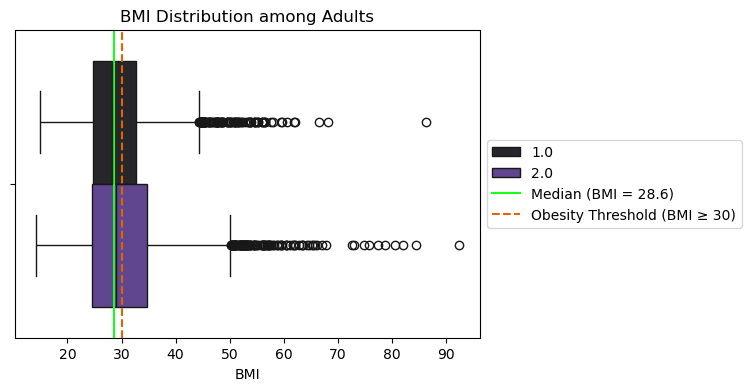

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_joined, color = '#5D3A9B', hue="gender")

# Calculate median
median_val = adults_joined['bmi'].median()

# Add vertical line for the median and include it in the legend
plt.axvline(median_val, color='#1AFF1A', linestyle='-', label=f"Median (BMI = {median_val:.1f})")

# Obesity threshold line
plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold (BMI ≥ 30)")

plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

As we can see, even at average, the weight distribution among adults doesn't fall into normal weight. In fact, the mean weight of this dataset, which is supposed to mimic the American population, is in the upper range of overweight bordering obesity. The weight of the Americans are overall increased.

However, there are significant outliers with values such as 92.3 which would increase average. To address the outlier, the decision was made to see how many subjects have BMI greater than 60.

In [17]:
num_high_bmi = (adults_joined['bmi'] >= 60).sum()
print(f"Number of subjects with BMI >= 60: {num_high_bmi}")
prop_high_bmi = (adults_joined['bmi'] >= 60).mean()
print(f"Proportion of subjects with BMI >= 60: {prop_high_bmi:.2%}")

Number of subjects with BMI >= 60: 36
Proportion of subjects with BMI >= 60: 0.41%


Out of the number of obese subjects, there are less than 1% of the dataset which have BMI equal to or greater thn 60. BMI of 60 is also not frequently encountered. Further elimination may be warranted. 

The decision was made to see how many subjects have BMI falling between 50 and 60.

In [18]:
# Count number of subjects with 50 <= BMI < 60
num_bmi_50_60 = ((adults_joined['bmi'] >= 50) & (adults_joined['bmi'] < 60)).sum()
print(f"Number of subjects with BMI between 50 and 60: {num_bmi_50_60}")
prop_bmi_50_60 = ((adults_joined['bmi'] >= 50) & (adults_joined['bmi'] < 60)).mean()
print(f"Proportion of subjects with BMI between 50 and 60: {prop_bmi_50_60:.2%}")

Number of subjects with BMI between 50 and 60: 135
Proportion of subjects with BMI between 50 and 60: 1.54%


Combining both of these values, the total proportion of adult subjects with BMI falling above 50 is 1.94%. The decision was made to drop those subjects whose BMI is greater than 50.

In [19]:
adults_filtered = adults_joined[adults_joined['bmi'] <= 50].copy()

In [20]:
adults_filtered['bmi'].describe()

count    8622.000000
mean       29.357237
std         6.583851
min        14.200000
25%        24.600000
50%        28.500000
75%        33.300000
max        50.000000
Name: bmi, dtype: float64

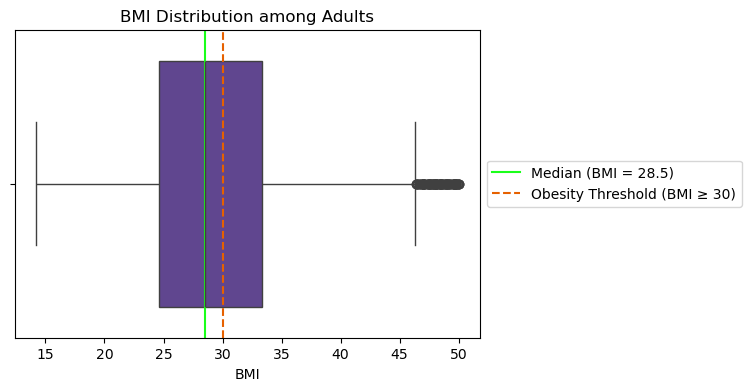

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_filtered, color = '#5D3A9B')

# Calculate median
median_val = adults_filtered['bmi'].median()

# Add vertical line for the median and include it in the legend
plt.axvline(median_val, color='#1AFF1A', linestyle='-', label=f"Median (BMI = {median_val:.1f})")

# Obesity threshold line
plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold (BMI ≥ 30)")

plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

As we can see, even with the outliers removed, the average weight of the subjects in this dataset still falls in the overweight range. The overall weight has increased in the American population.

Next step is to create a data frame with subjects that are obese by the BMI value.

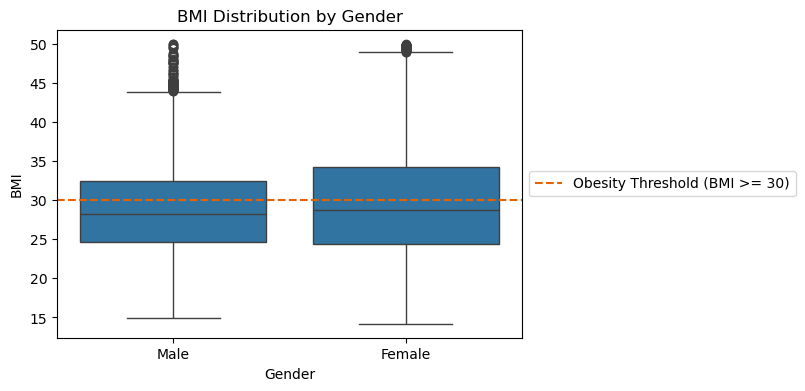

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender',y='bmi',data=adults_filtered)

plt.axhline(30, color='#E66100',linestyle='--', label= "Obesity Threshold (BMI >= 30)")
plt.title("BMI Distribution by Gender")
plt.ylabel('BMI')
plt.xlabel('Gender')
plt.xticks([0,1], ["Male" , "Female"])
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In [23]:
gender = adults_filtered.groupby('gender')['bmi'].describe()
gender = gender.rename(index={1: "Male", 2:"Female"})
gender

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Male,4225.0,28.956615,5.970412,14.9,24.7,28.2,32.4,50.0
Female,4397.0,29.742188,7.103129,14.2,24.4,28.8,34.2,50.0


The average BMI for women is higher compared to men. Women's bodies do need more fat for proper hormone regulation so it does make sense. The number of males and females in this dataset is about even.

In [24]:
obese = adults_filtered[adults_filtered['bmi'] >= 30]

In [25]:
obese.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,bmi,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.0,97.1,160.2,NaN,37.8,40.8,34.7,35.8,117.9,126.1
3,109274.0,1.0,68.0,7.0,4.0,3.0,1.2,103.7,185.3,NaN,30.2,44.0,47.0,32.0,109.6,107.8
5,109284.0,2.0,44.0,1.0,2.0,1.0,NaN,91.1,152.7,NaN,39.1,33.0,33.5,38.5,103.1,125.5
8,109291.0,2.0,42.0,6.0,5.0,1.0,NaN,81.4,161.3,NaN,31.3,NaN,NaN,NaN,NaN,NaN
9,109292.0,1.0,58.0,2.0,3.0,2.0,1.6,86.0,167.8,NaN,30.5,38.4,39.5,29.0,108.3,106.4


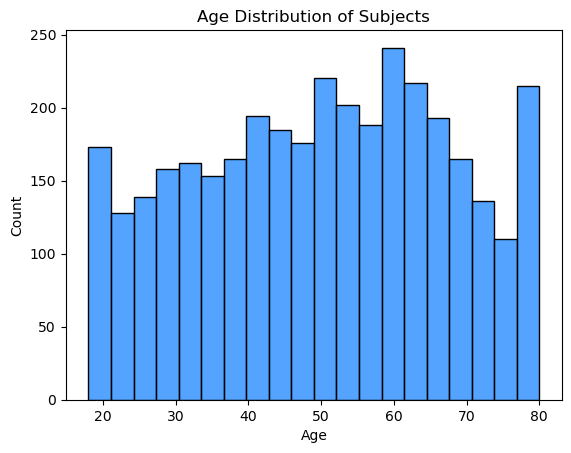

In [26]:
sns.histplot(x='age_year', bins = 20, data=obese, color = '#1A85FF')
plt.title('Age Distribution of Subjects')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The age distribution histogram seems to show that the general trend seems to be that as people age from their early 20s to early 60s, the obesity trend seems to peak and decrease until they get to late 70s. However, the trend appears to be quite weak. 

## Urine Albumin

The first urine lab value that will be analyzed against the BMI is the urine albumin. The urine creatinine and albumin tests are conducted as spot test, not as total excretion over 24 hours. 

For the assay conducted by NHANES lab, the unusual albumin values designated “< LOD” or > 1000 µg/mL are flagged for attention. The expected range is reported by multiple studies but for the purposes of the NHANES data, I decided to use what was reported based on NHANES dataset which is normal range should be <30 mcg/mL (Jones CA, Francis ME, Eberhardt MS, et al. Microalbuminuria in the US Population: Third National Health and Nutrition and Examination Survey. Am L Kidney Dis 2002;39: 445-459.)

To make the analysis and evaluation clearer, only the columns reflecting these units will be kept.

In [27]:
df_cralb = pd.read_csv('urine_cr_alb.csv')

In [28]:
urine_cralb = obese.merge(df_cralb, on='participant_id')

In [29]:
adults_cralb = adults_joined.merge(df_cralb, on='participant_id')

In [31]:
urine_cralb.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,...,hip_circ_cm,Unnamed: 0,albumin_urine_ug_mL,albumin_urine_mg_L,alb_comment,creatinine_urine_mg_dL,creatinine_urine_umol_L,creatinine_comment,alb_creat_ratio,collection_year
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,160.2,NaN,...,126.1,1,5.5,5.5,0.0,36.0,3182.4,0.0,15.28,2017-2020
1,109274.0,1.0,68.0,7.0,4.0,3.0,1.20,103.7,185.3,NaN,...,107.8,5,12.8,12.8,0.0,120.0,10608.0,0.0,10.67,2017-2020
2,109284.0,2.0,44.0,1.0,2.0,1.0,NaN,91.1,152.7,NaN,...,125.5,11,8.2,8.2,0.0,189.0,16707.6,0.0,4.34,2017-2020
3,109291.0,2.0,42.0,6.0,5.0,1.0,NaN,81.4,161.3,NaN,...,NaN,17,16.4,16.4,0.0,261.0,23072.4,0.0,6.28,2017-2020
4,109293.0,1.0,44.0,3.0,3.0,3.0,0.02,99.4,181.6,NaN,...,120.2,19,7.2,7.2,0.0,57.0,5038.8,0.0,12.63,2017-2020


In [32]:
urine_cralb.shape

(3448, 25)

In [33]:
urine_cralb.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'education_level',
       'marital_status', 'family_income_poverty', 'weight_kg',
       'standing_height', 'standing_height_comment', 'bmi', 'upper_leg_cm',
       'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm',
       'Unnamed: 0', 'albumin_urine_ug_mL', 'albumin_urine_mg_L',
       'alb_comment', 'creatinine_urine_mg_dL', 'creatinine_urine_umol_L',
       'creatinine_comment', 'alb_creat_ratio', 'collection_year'],
      dtype='object')

In [34]:
urine_cralb = urine_cralb[['participant_id','gender','age_year','race','bmi',
'albumin_urine_ug_mL', 'creatinine_urine_mg_dL','alb_creat_ratio']]

In [36]:
urine_cralb.isna().sum()

participant_id            0
gender                    0
age_year                  0
race                      0
bmi                       0
albumin_urine_ug_mL       0
creatinine_urine_mg_dL    0
alb_creat_ratio           0
dtype: int64

With the initial data cleaning, the NaN values have been removed. 

In [38]:
urine_cralb.describe()

,participant_id,gender,age_year,race,bmi,albumin_urine_ug_mL,creatinine_urine_mg_dL,alb_creat_ratio
count,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000
mean,117062.047564,1.545244,49.816995,3.266531,35.782570,63.937558,142.477378,57.838222
std,4564.177792,0.498021,17.155913,1.471719,4.709608,405.712906,88.483911,371.666530
min,109266.000000,1.000000,18.000000,1.000000,30.000000,0.300000,8.000000,0.860000
25%,113031.000000,1.000000,36.000000,3.000000,32.000000,5.500000,76.000000,4.960000
50%,116966.500000,2.000000,51.000000,3.000000,34.600000,10.600000,126.500000,7.880000
75%,121099.500000,2.000000,63.000000,4.000000,38.500000,22.800000,190.000000,16.122500
max,124818.000000,2.000000,80.000000,7.000000,50.000000,14040.000000,609.000000,11055.120000


In [40]:
urine_alb = urine_cralb[['participant_id','gender','age_year','bmi','albumin_urine_ug_mL', 'race']]

In [41]:
urine_alb['albumin_urine_ug_mL'].describe()

count     3448.000000
mean        63.937558
std        405.712906
min          0.300000
25%          5.500000
50%         10.600000
75%         22.800000
max      14040.000000
Name: albumin_urine_ug_mL, dtype: float64

Although the range of the urine albumin can be a bit ambiguous, values that are significantly above 1000 mcg/mL seems to be too extreme. The data was visualized to see how the distribution appears.

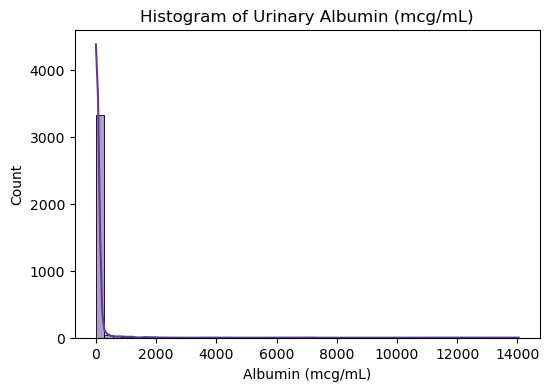

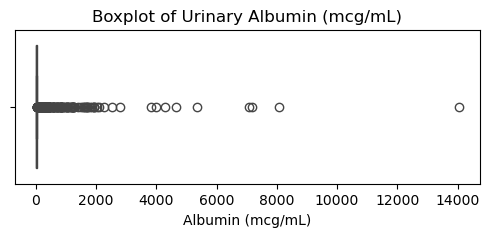

In [42]:
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(urine_alb['albumin_urine_ug_mL'], bins=50, kde=True, color='#5D3A9B')
plt.title("Histogram of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_alb['albumin_urine_ug_mL'], color='#E66100')
plt.title("Boxplot of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.show()

Because the urine albumin range can be a bit arbitrary, dropping of outliers may not be the best route. However, the 14,000 value should be removed since that is unlikely that the urine albumin level would be that high in the clinical setting. 

The question that arises with this level of albumin is, what is the health status of these subjects? Are they higher in the BMI range than other subjects that have more "reasonable" albumin range? 

In [43]:
urine_alb = urine_alb[urine_alb['albumin_urine_ug_mL'] != 14040]

In [44]:
urine_alb['albumin_flag'] = urine_alb['albumin_urine_ug_mL'].apply(lambda x: 'High' if x >= 1000 else 'Normal')

C:\Users\chungs4\AppData\Local\Temp\ipykernel_18456\4157928887.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='albumin_flag', y='albumin_urine_ug_mL', data=urine_alb, palette=['#5D3A9B','#E66100'])


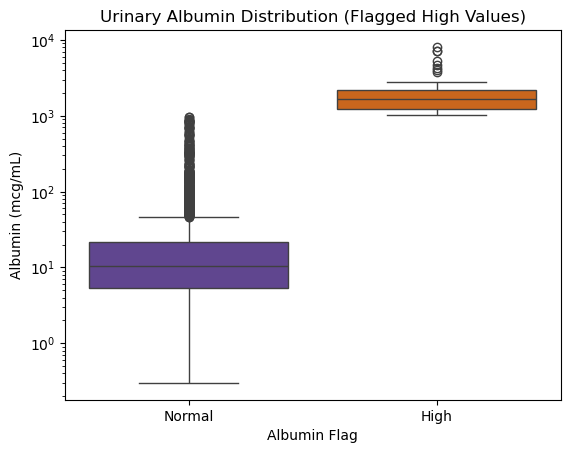

In [45]:
sns.boxplot(x='albumin_flag', y='albumin_urine_ug_mL', data=urine_alb, palette=['#5D3A9B','#E66100'])
plt.yscale('log')  # Optional: log-scale to better show distribution
plt.title("Urinary Albumin Distribution (Flagged High Values)")
plt.xlabel('Albumin Flag')
plt.ylabel('Albumin (mcg/mL)')
plt.show()

In [46]:
# Define your threshold
threshold = 1000  

# Count how many subjects exceed the threshold
extreme_count = (urine_alb['albumin_urine_ug_mL'] >= threshold).sum()

# Total number of subjects
total_count = urine_alb['albumin_urine_ug_mL'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme albumin values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with albumin values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")


Subjects with extreme albumin values (≥ 1000 µg/mL): 43
Total subjects with albumin values: 3447
Percentage extreme: 1.25%


Although the albumin values are not inherently critical at an elevated level, values above 1000 mcg/mL are highly unusual. As we can see, only 1.25% (43 out of 3447) of the subjects have this extreme value above 1000 mcg/mL. The decision was made to remove these subjects to have a more representative dataset for analysis. 

In [47]:
# Define threshold
threshold = 1000  

# Keep only subjects below threshold
urine_alb_clean = urine_alb[urine_alb['albumin_urine_ug_mL'] < threshold].copy()

print(f"Original: {urine_alb.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_alb_clean.shape[0]} rows")


Original: 3447 rows
After removing extreme albumin values: 3404 rows


In [48]:
extreme_subjects = urine_alb[urine_cralb['albumin_urine_ug_mL'] >= threshold]

C:\Users\chungs4\AppData\Local\Temp\ipykernel_18456\3687547731.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  extreme_subjects = urine_alb[urine_cralb['albumin_urine_ug_mL'] >= threshold]


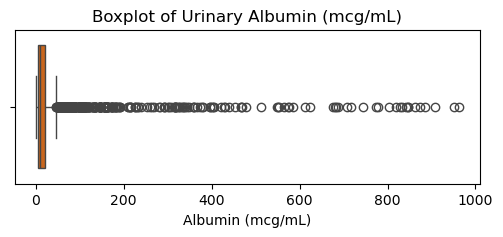

In [49]:
plt.figure(figsize=(6,2))
sns.boxplot(x=urine_alb_clean['albumin_urine_ug_mL'], color='#E66100')
plt.title("Boxplot of Urinary Albumin (mcg/mL)")
plt.xlabel("Albumin (mcg/mL)")
plt.show()

In [50]:
urine_alb_clean.describe()

,participant_id,gender,age_year,bmi,albumin_urine_ug_mL,race
count,3404.000000,3404.000000,3404.000000,3404.000000,3404.000000,3404.000000
mean,117071.677732,1.546710,49.774677,35.767039,31.734929,3.263514
std,4560.132234,0.497887,17.187512,4.710558,85.467464,1.469509
min,109266.000000,1.000000,18.000000,30.000000,0.300000,1.000000
25%,113050.500000,1.000000,36.000000,32.000000,5.400000,3.000000
50%,116979.500000,2.000000,50.000000,34.600000,10.400000,3.000000
75%,121101.750000,2.000000,63.000000,38.500000,21.825000,4.000000
max,124818.000000,2.000000,80.000000,50.000000,962.000000,7.000000


With the outliers removed, the average value of the urine albumin is 31 mcg/mL which is about the reference range from the NHANES study. 

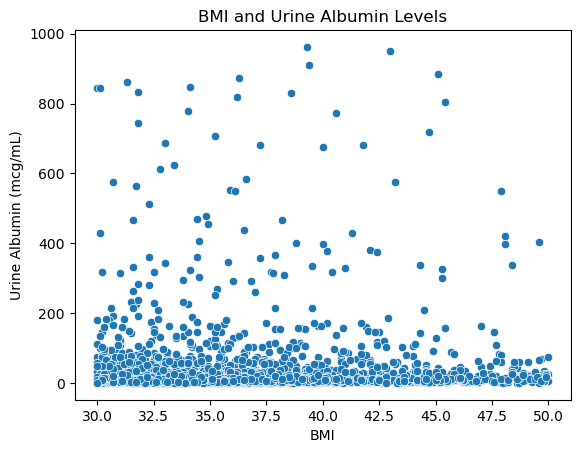

In [51]:
sns.scatterplot(x='bmi',y='albumin_urine_ug_mL',data=urine_alb_clean)
plt.xlabel('BMI')
plt.ylabel('Urine Albumin (mcg/mL)')
plt.title('BMI and Urine Albumin Levels')
plt.show()

<Axes: xlabel='bmi', ylabel='albumin_urine_ug_mL'>

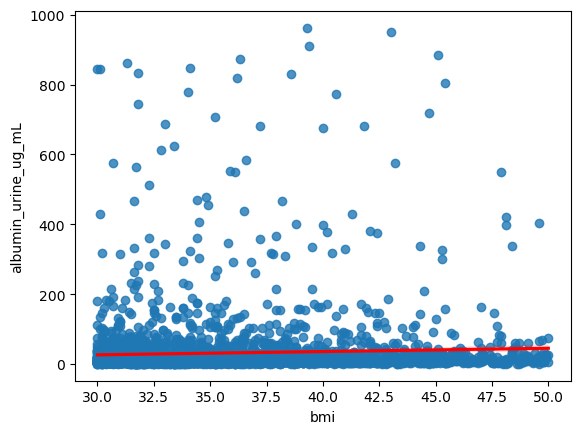

In [52]:
sns.regplot(x='bmi',y='albumin_urine_ug_mL',data=urine_alb_clean,line_kws={"color": "red"})

There does not seem to be any linear relationship between the urine albumin level and BMI overall. It will be worthwhile to see whether there is any difference when separated by gender/sex. 

In [53]:
albumin_stats = urine_alb_clean.groupby("gender")["albumin_urine_ug_mL"].describe()
print(albumin_stats)

         count       mean        std  min   25%   50%   75%    max
gender                                                            
1.0     1543.0  36.143487  94.503095  0.4  5.65  10.7  23.7  885.0
2.0     1861.0  28.079688  77.012953  0.3  5.20  10.1  20.9  962.0


1 is male and 2 is female.

C:\Users\chungs4\AppData\Local\Temp\ipykernel_18456\26042211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="gender", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2", cut=0)


(0.0, 150.0)

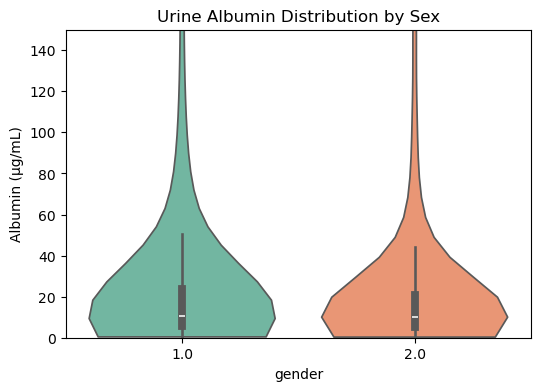

In [54]:
plt.figure(figsize=(6,4))
sns.violinplot(x="gender", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2", cut=0)
plt.title("Urine Albumin Distribution by Sex")
plt.ylabel("Albumin (µg/mL)")
plt.ylim(0, 150)

C:\Users\chungs4\AppData\Local\Temp\ipykernel_18456\3194978940.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2")


(0.0, 150.0)

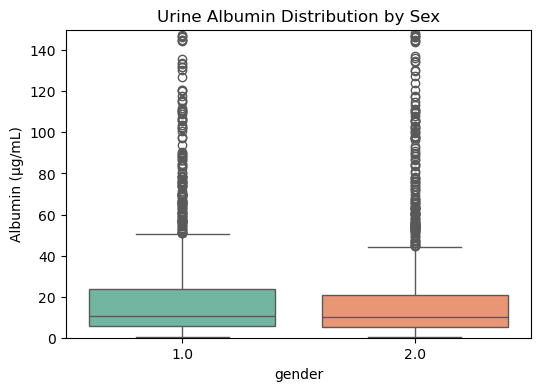

In [55]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="albumin_urine_ug_mL", data=urine_alb_clean, palette="Set2")
plt.title("Urine Albumin Distribution by Sex")
plt.ylabel("Albumin (µg/mL)")
plt.ylim(0,150)

Separation and grouping the data by gender does not seem to change the median value of the urine albumin by much. 

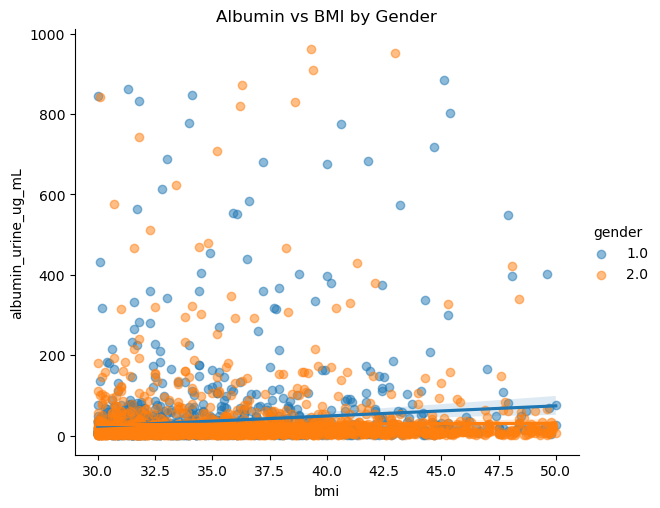

In [56]:
sns.lmplot(
    x="bmi",
    y="albumin_urine_ug_mL",
    hue="gender",
    data=urine_alb_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)

plt.title("Albumin vs BMI by Gender")
plt.show()

When regression plot is created, however, it does seem like the male population may some positive correlation with BMI. Further statistical analysis was performed to evaluate the numerical values

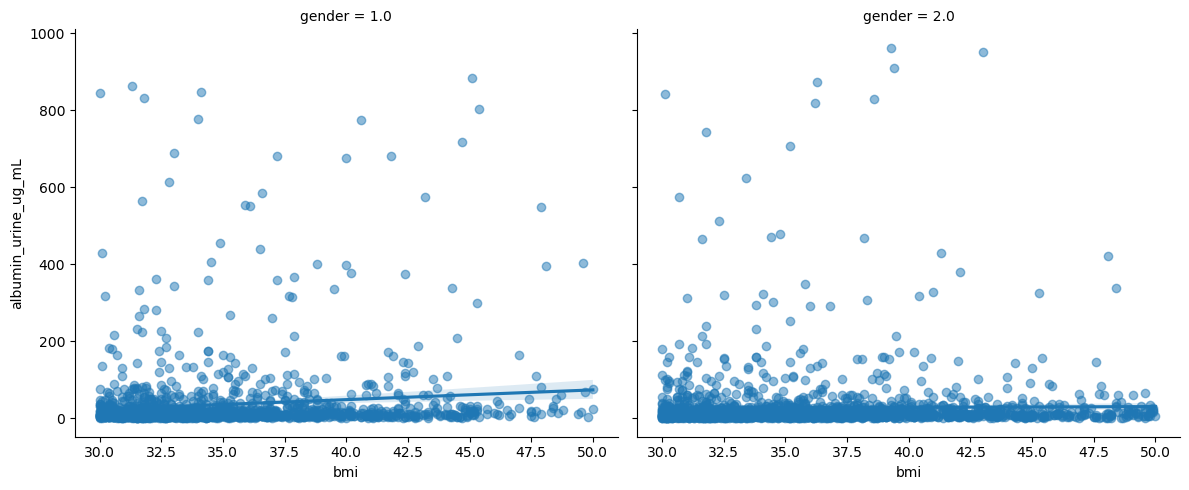

In [57]:
sns.lmplot(
    x="bmi",
    y="albumin_urine_ug_mL",
    col="gender",
    data=urine_alb_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

It appears that the slope of the regression line is slightly higher in the male population than the female population. The correlation will have to be calculated and observed to see whether that is also appreciated in the numeric form.

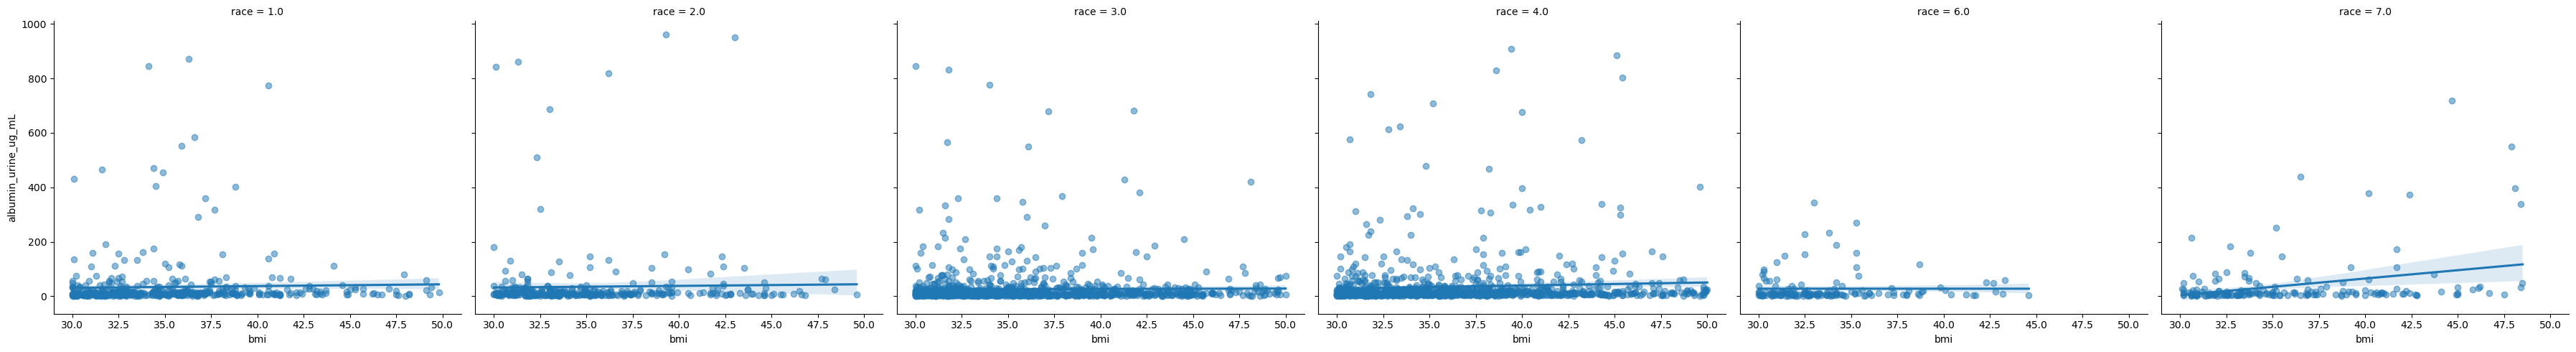

In [58]:
sns.lmplot(
    x="bmi",
    y="albumin_urine_ug_mL",
    col="race",
    data=urine_alb_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

There seems to be possibly some correlation with "Other" race which includes mixed races. That is a bit difficult to interpret since the race or ethnicity is not specified in that group. 

In [59]:
from scipy.stats import linregress

# Loop over genders
for sex in urine_alb_clean['gender'].unique():
    subset = urine_alb_clean[urine_alb_clean['gender'] == sex]
    slope, intercept, r_value, p_value, std_err = linregress(subset['bmi'], subset['albumin_urine_ug_mL'])
    print(f"{sex}: slope={slope:.4f}, intercept={intercept:.2f}, r={r_value:.4f}, p={p_value:.4g}")


2.0: slope=0.1693, intercept=21.93, r=0.0109, p=0.6378
1.0: slope=2.5274, intercept=-52.58, r=0.1147, p=6.291e-06


When looking at the slope, the raw value is higher in the male population but in the grand scheme of the lab values overall, even comparing to the standard deviation of the lab values, the slope is not impressive.

In [60]:
# List non-numeric columns
non_numeric = urine_alb_clean.select_dtypes(exclude='number').columns
print(non_numeric)

# Or check types of all columns
print(urine_alb_clean.dtypes)


Index(['albumin_flag'], dtype='object')
participant_id         float64
gender                 float64
age_year               float64
bmi                    float64
albumin_urine_ug_mL    float64
race                   float64
albumin_flag            object
dtype: object


In [61]:
urine_alb_clean = urine_alb_clean.drop(['albumin_flag'], axis=1)

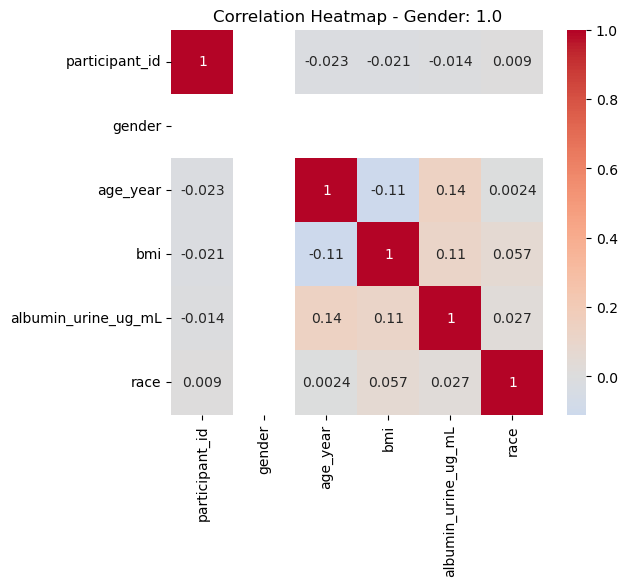

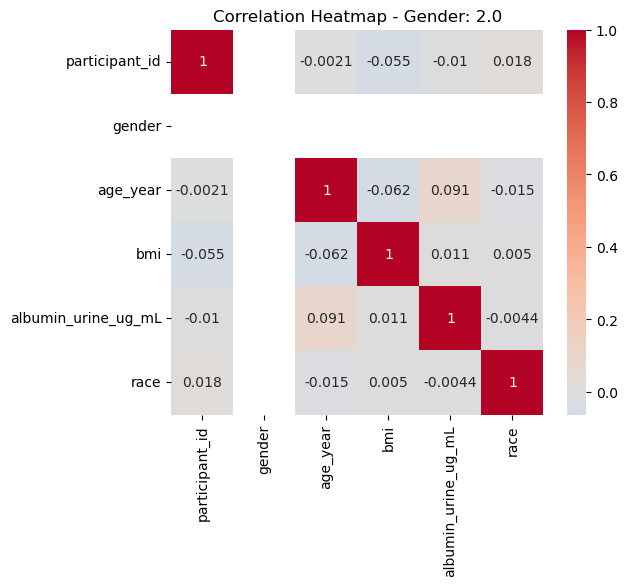

In [62]:
for gender, df_group in urine_alb_clean.groupby('gender'):
    corr_matrix = df_group.corr()
    
    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Heatmap - Gender: {gender}')
    plt.show()

The closer to the value of 0, the less there is a relationship between two values. Looking at the correlation table, it does appear that with urine albumin level overall does not seem to have a strong correlation with BMI (0.052). When the genders are separated, the correlation with albumin level seems to be _____.

## Urine Creatinine

Next, urine creatinine will be analyzed.

According to the laboratory test that was performed for the purposes of NHANES, the normal range for urine creatinine is as reported as follows:

 * Urine, adult male, first morning void: 40-278 mg/dL
 * Urine, adult female, first morning void: 29-226 mg/dL

(Mazzachi, et al. From the Roche reagent package insert for enzymatic creatinine.)

In [63]:
urine_cr = urine_cralb[['participant_id','gender','age_year','race','bmi',
'creatinine_urine_mg_dL']]

In [64]:
urine_cr.describe()

,participant_id,gender,age_year,race,bmi,creatinine_urine_mg_dL
count,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000,3448.000000
mean,117062.047564,1.545244,49.816995,3.266531,35.782570,142.477378
std,4564.177792,0.498021,17.155913,1.471719,4.709608,88.483911
min,109266.000000,1.000000,18.000000,1.000000,30.000000,8.000000
25%,113031.000000,1.000000,36.000000,3.000000,32.000000,76.000000
50%,116966.500000,2.000000,51.000000,3.000000,34.600000,126.500000
75%,121099.500000,2.000000,63.000000,4.000000,38.500000,190.000000
max,124818.000000,2.000000,80.000000,7.000000,50.000000,609.000000


Because the urine creatinine normal range is varied by gender, the first step is to visualize how the spread differs by the gender. 

C:\Users\chungs4\AppData\Local\Temp\ipykernel_18456\3716289073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="creatinine_urine_mg_dL", data=urine_cr, palette="Set2")


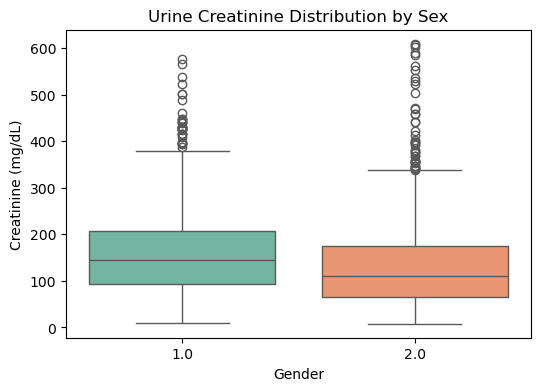

In [65]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="creatinine_urine_mg_dL", data=urine_cr, palette="Set2")
plt.title("Urine Creatinine Distribution by Sex")
plt.ylabel("Creatinine (mg/dL)")
plt.xlabel("Gender")
plt.show()

There are some outliers but it apperas that most of these values fall within the normal range as specified above. The decision was made to keep all of these values, as the outliers do not seem to be skewing the data too much. 

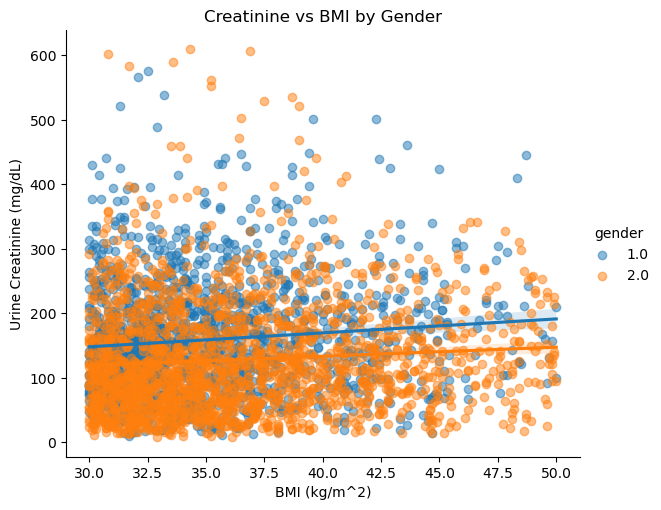

In [66]:
sns.lmplot(
    x="bmi",
    y="creatinine_urine_mg_dL",
    hue="gender",
    data=urine_cr,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)

plt.title("Creatinine vs BMI by Gender")
plt.ylabel("Urine Creatinine (mg/dL)")
plt.xlabel("BMI (kg/m^2)")
plt.show()

The linear regression line does not seem to have a strong slope or correlation. Male subjects seem to have a slightly stronger positive correlation compared to the female subjects but both lines' slopes seem to be minimal. 

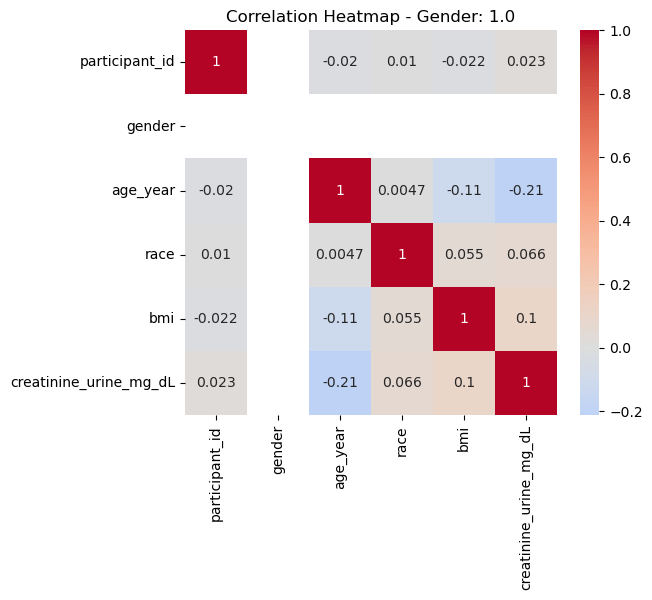

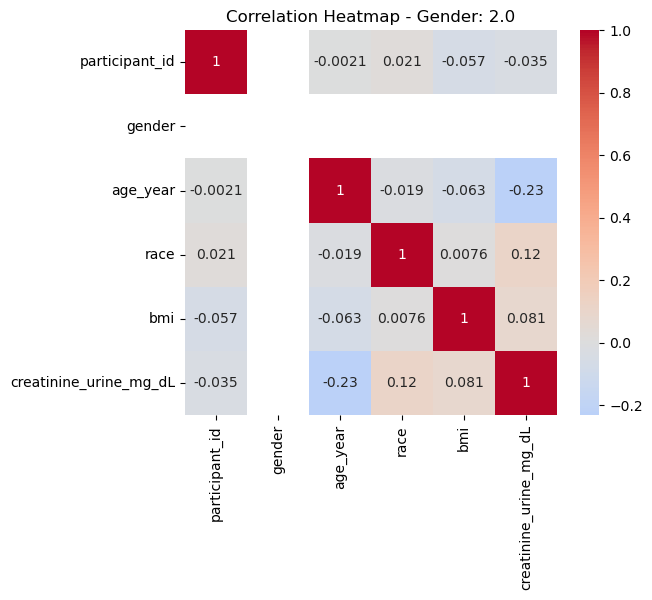

In [67]:
for gender, df_group in urine_cr.groupby('gender'):
    # compute correlation within this gender group
    corr_matrix = df_group.corr()

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Heatmap - Gender: {gender}')
    plt.show()

The correlation seen between BMI and urine creatinine is 0.067, which means there is no correlation between those two values. 

## Urine Iodine

Iodine is necessary for thyroid function which contribute to the metabolism in the body. Urine iodine secretion 

Median urinary iodine concentrations of 100–199 mcg/L in children and adults, 150–249 mcg/L in pregnant women and >100 mcg/L in lactating women indicate iodine intakes are adequate (https://ods.od.nih.gov/factsheets/Iodine-HealthProfessional/#:~:text=The%20iodine%2Dreplete%20healthy%20adult,intakes%20are%20adequate%20%5B3%5D.)

In [68]:
iodine = pd.read_csv('cleaned_u_iodine.csv')

In [69]:
urine_iodine = obese.merge(iodine, on='participant_id')

In [70]:
urine_iodine.shape

(1119, 18)

After joining the tables on `participant_id`, the total number of rows/subjects left is 1119. 

Is there a way to calculate for power? 
Lab results are not normalized so it will have to use non-parametric statistical tests. 

In [71]:
urine_iodine.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,standing_height,standing_height_comment,bmi,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm,urine_iodine,urine_iodine_comment
0,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,160.2,NaN,37.8,40.8,34.7,35.8,117.9,126.1,50.6,0.0
1,109274.0,1.0,68.0,7.0,4.0,3.0,1.20,103.7,185.3,NaN,30.2,44.0,47.0,32.0,109.6,107.8,265.3,0.0
2,109316.0,2.0,62.0,4.0,3.0,2.0,0.07,77.2,159.2,NaN,30.5,40.5,38.5,35.7,97.5,102.0,80.1,0.0
3,109317.0,2.0,28.0,4.0,4.0,3.0,NaN,91.6,174.5,NaN,30.1,45.9,36.1,35.2,100.3,121.3,117.1,0.0
4,109321.0,2.0,19.0,4.0,NaN,NaN,0.06,83.5,158.7,NaN,33.2,39.9,36.6,34.5,96.7,114.4,301.6,0.0


In [72]:
urine_iodine = urine_iodine[['participant_id','race','gender','bmi','urine_iodine']]

In [73]:
urine_iodine.head()

,participant_id,race,gender,bmi,urine_iodine
0,109266.0,6.0,2.0,37.8,50.6
1,109274.0,7.0,1.0,30.2,265.3
2,109316.0,4.0,2.0,30.5,80.1
3,109317.0,4.0,2.0,30.1,117.1
4,109321.0,4.0,2.0,33.2,301.6


In [74]:
urine_iodine.describe()

,participant_id,race,gender,bmi,urine_iodine
count,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000
mean,116989.534406,3.280608,1.545130,35.746202,244.438159
std,4589.640141,1.478495,0.498182,4.711354,719.650714
min,109266.000000,1.000000,1.000000,30.000000,10.200000
25%,112942.000000,3.000000,1.000000,31.950000,75.950000
50%,116993.000000,3.000000,2.000000,34.600000,131.300000
75%,121013.500000,4.000000,2.000000,38.300000,248.650000
max,124794.000000,7.000000,2.000000,50.000000,17426.300000


C:\Users\chungs4\AppData\Local\Temp\ipykernel_18456\4229755988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine, palette="Set2")


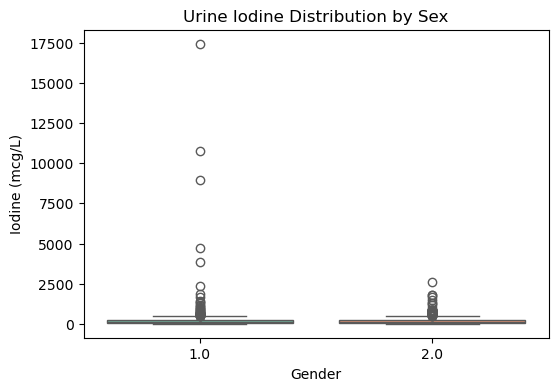

In [75]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

The urine iodine unit is mcg/L. The value that is in the 10,000 seems to be way too excessive. The typical concern with urine iodine is reduced output which equates to inadequate intake to support normal physiological functions. However, the upper range in this cohort is in the 10,000 mcg/L which seems to be excessive. Much like the albumin and creatinine, the outliers should be removed for a proper analysis. From the descriptive statistics and the visualization, having a cutoff of 2500 mcg/L appears to be adequate. 

In [76]:
# Define your threshold
threshold = 2500  

# Count how many subjects exceed the threshold
extreme_count = (urine_iodine['urine_iodine'] >= threshold).sum()

# Total number of subjects
total_count = urine_iodine['urine_iodine'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme iodine values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with iodine values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

Subjects with extreme iodine values (≥ 2500 µg/mL): 6
Total subjects with iodine values: 1119
Percentage extreme: 0.54%


In [77]:
# Keep only subjects below threshold
urine_iodine_clean = urine_iodine[urine_iodine['urine_iodine'] < threshold].copy()

print(f"Original: {urine_iodine.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_iodine_clean.shape[0]} rows")


Original: 1119 rows
After removing extreme albumin values: 1113 rows


In [78]:
urine_iodine_clean.describe()

,participant_id,race,gender,bmi,urine_iodine
count,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000
mean,116982.694519,3.283019,1.547170,35.748518,202.357682
std,4592.973628,1.481252,0.497994,4.697845,227.592971
min,109266.000000,1.000000,1.000000,30.000000,10.200000
25%,112929.000000,3.000000,1.000000,32.000000,75.800000
50%,116963.000000,3.000000,2.000000,34.600000,130.600000
75%,121041.000000,4.000000,2.000000,38.300000,247.500000
max,124794.000000,7.000000,2.000000,50.000000,2337.000000


C:\Users\chungs4\AppData\Local\Temp\ipykernel_18456\938092668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine_clean, palette="Set2")


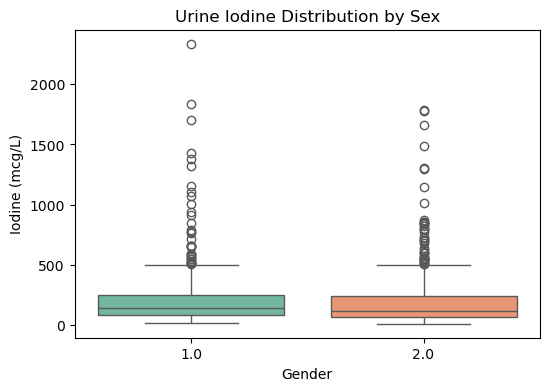

In [79]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine_clean, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

After removing the values that are greather than or equal to 2500, the plot still shows quite a bit of variance and outliers. The decision was then made to limit the upper value of iodine to 1000 mcg/L.

In [80]:
# Define your threshold
threshold = 1000 

# Count how many subjects exceed the threshold
extreme_count = (urine_iodine_clean['urine_iodine'] >= threshold).sum()

# Total number of subjects
total_count = urine_iodine_clean['urine_iodine'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme iodine values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with iodine values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

Subjects with extreme iodine values (≥ 1000 µg/mL): 18
Total subjects with iodine values: 1113
Percentage extreme: 1.62%


In [81]:
# Keep only subjects below threshold
urine_iodine_clean = urine_iodine[urine_iodine['urine_iodine'] < threshold].copy()

print(f"Original: {urine_iodine.shape[0]} rows")
print(f"After removing extreme albumin values: {urine_iodine_clean.shape[0]} rows")

Original: 1119 rows
After removing extreme albumin values: 1095 rows


In [82]:
urine_iodine_clean.describe()

,participant_id,race,gender,bmi,urine_iodine
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,116951.882192,3.284018,1.548858,35.739361,182.107215
std,4593.856656,1.483816,0.497834,4.708122,159.061259
min,109266.000000,1.000000,1.000000,30.000000,10.200000
25%,112888.000000,3.000000,1.000000,31.950000,75.450000
50%,116928.000000,3.000000,2.000000,34.600000,127.900000
75%,121013.500000,4.000000,2.000000,38.300000,240.200000
max,124794.000000,7.000000,2.000000,50.000000,938.200000


C:\Users\chungs4\AppData\Local\Temp\ipykernel_18456\938092668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine_clean, palette="Set2")


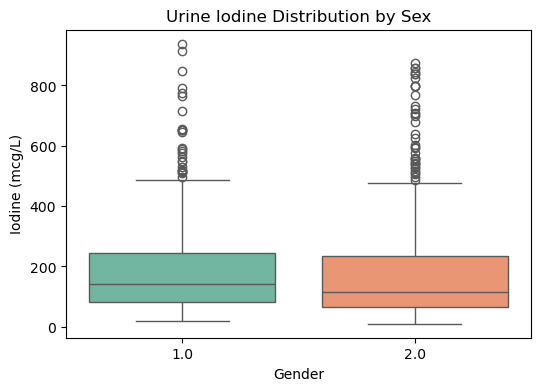

In [83]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="urine_iodine", data=urine_iodine_clean, palette="Set2")
plt.title("Urine Iodine Distribution by Sex")
plt.ylabel("Iodine (mcg/L)")
plt.xlabel("Gender")
plt.show()

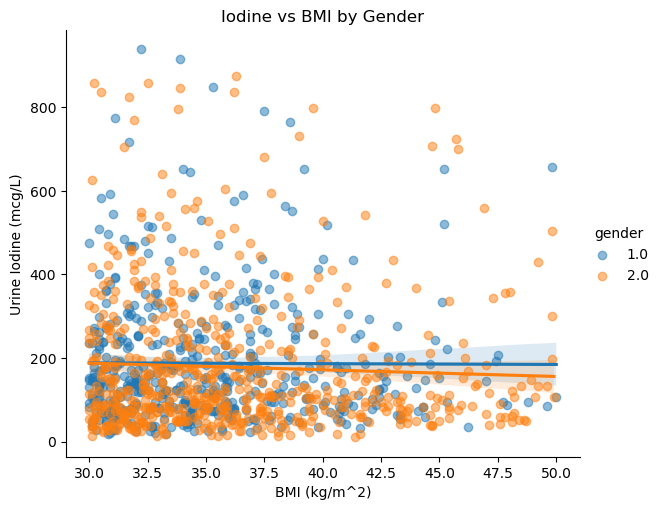

In [84]:
sns.lmplot(
    x="bmi",
    y="urine_iodine",
    hue="gender",
    data=urine_iodine_clean,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)

plt.title("Iodine vs BMI by Gender")
plt.ylabel("Urine Iodine (mcg/L)")
plt.xlabel("BMI (kg/m^2)")
plt.show()

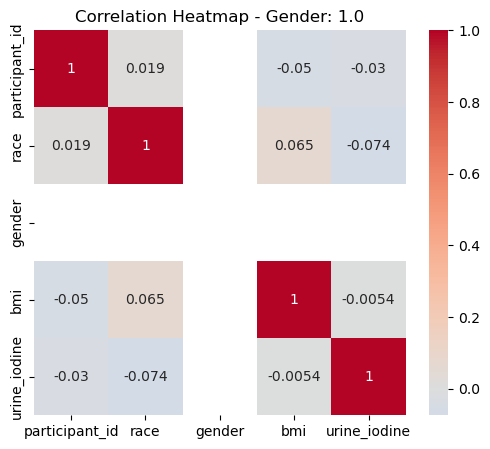

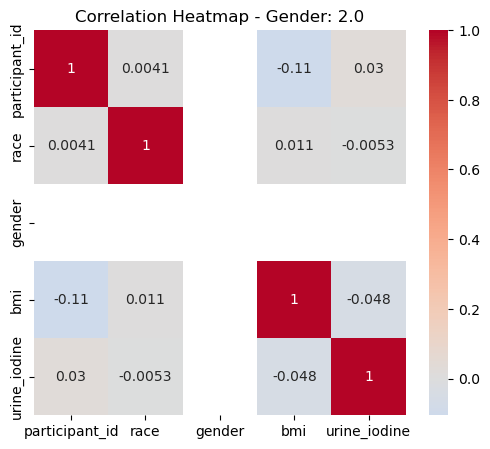

In [85]:
for gender, df_group in urine_iodine_clean.groupby('gender'):
    # compute correlation within this gender group
    corr_matrix = df_group.corr()

    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Heatmap - Gender: {gender}')
    plt.show()

There is no strong correlation between BMI and urine iodine levels. The regression plot shows perhaps slight negative correlation but the slope does not seem to be significant. The correlation heatmap shows that there is no substantial correlation between BMI and urine iodine, although the direction of the correlation is negative. 

### Conclusion

Based on the analysis performed with NHANES urine dataset, there was no substantial correlation between the urine creatinine, albumin, or iodine with BMI. There were slight difference between genders in the urine albumin and urine iodine but neither were significant enough to make associations with. 

These findings are reasonable since the urine labs are more related to kidney function and overall nutritional status of a person. Obesity is the pathology caused by metabolic imbalance. 

The next analysis that should be peformed should be comparing how these values differ between normal BMI popultion and obese BMI population. 